# TyrePIML Benchmark
## Physics-Informed ML for F1 Tyre Degradation Prediction
**ML4SCI — GSoC 2026**

This notebook benchmarks two models on the tyre degradation prediction task:
- **Baseline LSTM** — standard sequence model trained on F1 telemetry
- **PIML LSTM** — physics-constrained variant enforcing monotonic tyre degradation

Data source: FastF1 | Races: Monza, Silverstone, Spa (2022-2023)

In [1]:
import sys
sys.path.append('..')

import torch
from torch.utils.data import random_split
from src.dataset import TyreDataset, denormalize, LAP_TIME_MIN, LAP_TIME_MAX
from src.model import TyreLSTM
from src.compare import evaluate_model
from src.violations import count_violations
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("All imports successful!") 

All imports successful!


## Dataset Summary
5 race weekends across 2022-2023 seasons, cleaned and normalized.

In [2]:
import glob
import os

files = glob.glob('../data/*.csv')

rows = []
for file in sorted(files):
    df = pd.read_csv(file)
    race = os.path.basename(file).replace('.csv', '')
    rows.append({
        'Race': race,
        'Laps': len(df),
        'Drivers': df['Driver'].nunique(),
        'Compounds': ', '.join(sorted(df['Compound'].unique()))
    })

summary = pd.DataFrame(rows)
summary.loc['Total'] = ['ALL', summary['Laps'].sum(), '-', '-']
summary 

,Race,Laps,Drivers,Compounds
0,2022_Monza,835,20,"HARD, MEDIUM, SOFT"
1,2022_Silverstone,696,17,"HARD, MEDIUM, SOFT"
2,2023_Monza,903,19,"HARD, MEDIUM"
3,2023_Silverstone,827,20,"HARD, MEDIUM, SOFT"
4,2023_Spa,1249,20,"HARD, MEDIUM, SOFT"
Total,ALL,4510,-,-


## Model Comparison Results
Baseline LSTM vs Physics-Informed LSTM evaluated on 666 held-out validation sequences.

In [3]:
# Load saved results
results = pd.read_csv('../results/comparison_table.csv')
results

,Metric,Baseline LSTM,PIML LSTM
0,MAE (seconds),0.5960,0.7581
1,RMSE (seconds),1.0786,1.1722
2,Violation Rate (%),52.0500,47.9500


## Predicted vs Actual Lap Times
Both models plotted against real lap times on the validation set.

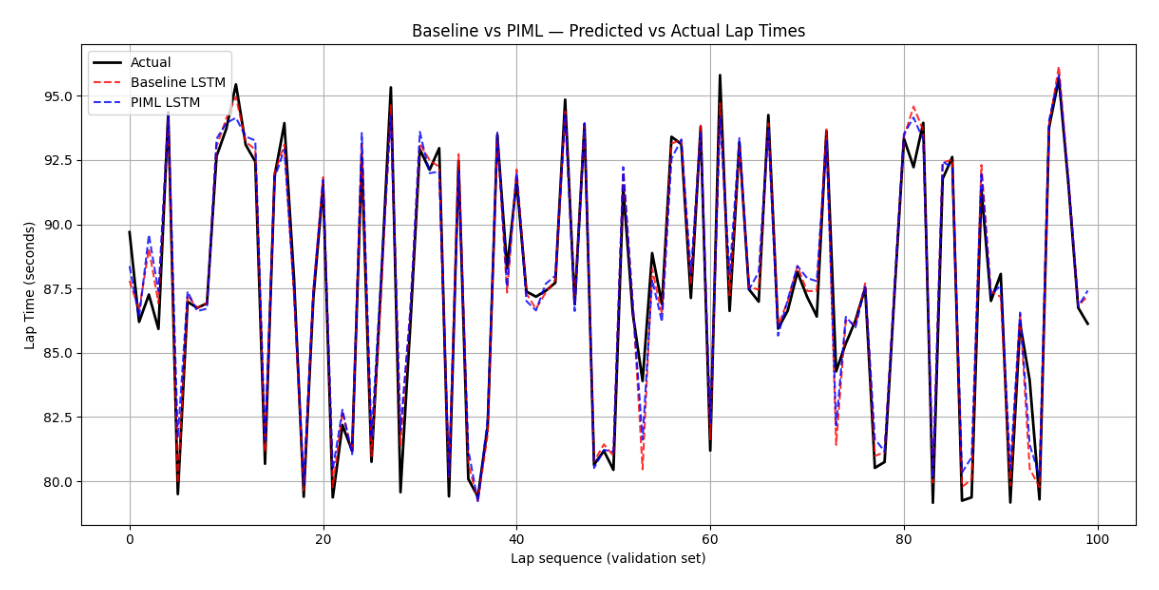

In [4]:
from PIL import Image

img = Image.open('../results/comparison_plot.png')
plt.figure(figsize=(14, 6))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

In [1]:
# Model Architecture Comparison — Transformer vs LSTM
import pandas as pd

results = {
    'Model': ['LSTM (Generic)', 'Transformer (Generic)', 'Compound Models', 'Track-Specific Models'],
    'Architecture': ['LSTM 2-layer', 'Transformer 2-layer', 'Transformer per compound', 'Transformer per circuit'],
    'Parameters': ['51,521', '102,721', '~50K each', '~50K each'],
    'Val Loss': [0.0008, 0.0007, '0.0007-0.0014', '0.0003-0.0015'],
    'MAE (seconds)': [1.186, 1.037, 1.928, 1.274],
    'Training Data': ['2018-2022', '2018-2024', '2018-2024 per compound', 'All races per circuit'],
}

df = pd.DataFrame(results)
df

,Model,Architecture,Parameters,Val Loss,MAE (seconds),Training Data
0,LSTM (Generic),LSTM 2-layer,"51,521",0.0008,1.186,2018-2022
1,Transformer (Generic),Transformer 2-layer,"102,721",0.0007,1.037,2018-2024
2,Compound Models,Transformer per compound,~50K each,0.0007-0.0014,1.928,2018-2024 per compound
3,Track-Specific Models,Transformer per circuit,~50K each,0.0003-0.0015,1.274,All races per circuit


In [ ]:
# Val Loss Progression — Clean Story for Paper
import matplotlib.pyplot as plt

models = ['LSTM\nBaseline', 'Transformer\nv1', 'Transformer\n+Thermal']
val_losses = [0.0008, 0.0007, 0.0006]
colors = ['#3a3a3a', '#6B7C3F', '#C9A84C']

fig, ax = plt.subplots(figsize=(8, 5), facecolor='#1E1E1E')
ax.set_facecolor('#1E1E1E')
bars = ax.bar(models, val_losses, color=colors, width=0.5, edgecolor='#2a2a2a')
ax.set_ylabel('Validation Loss', color='#F0EDE4')
ax.set_title('Model Progression — Physics Features Drive Improvement', 
             color='#C9A84C', fontsize=12)
ax.tick_params(colors='#F0EDE4')
for spine in ax.spines.values():
    spine.set_edgecolor('#3a3a3a')
for bar, val in zip(bars, val_losses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00001,
            f'{val}', ha='center', va='bottom', color='#F0EDE4', fontsize=10)
plt.tight_layout()
plt.savefig('../results/model_progression.png', facecolor='#1E1E1E', dpi=150)
plt.show()
print("Saved to results/model_progression.png") 